Subgraph is replacing one node of graph with full node or with a graph.

SubGraph can be implemented through two ways:

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [ ]:
class State(TypedDict):
    question: str
    answer: str
    summary: str
    explanation: str #it will be implemented in seperate graph to implement graph 
    final_response: str

In [3]:
def answer_node(state: State):
    print(state['question'])
    answer = "Answer: imagine answer is 6 + 6 = 12"
    return {
        "answer": answer
    }

In [4]:
def summary_node(state: State):
    print(state['answer'])
    summary = "Summary: 6 + 6 = 12"
    return{
        "summary": summary
    }

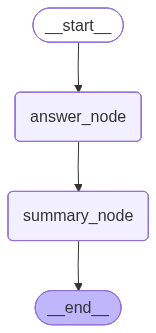

In [5]:
graph = StateGraph(State)
graph.add_node(answer_node, 'answer_node')
graph.add_node(summary_node, 'summary_node')
graph.add_edge(START, 'answer_node')
graph.add_edge('answer_node', 'summary_node')
graph.add_edge('summary_node', END)

first_graph = graph.compile()
first_graph

First Graph done creating second graph ... first graph will be added as subgraph in the second graph

In [6]:
def explain_node(state : State)-> dict:
    print(state['summary'])
    explanation = 'As the question is 6 + 6 in math if we count it gets equal to 12'
    return{
        "explanation":explanation
    }

In [ ]:
def final_node(state : State)-> dict:
    print(state['explanation'])
    final = 'This is a simple mathematics question .As the question is 6 + 6 in math if we count it gets equal to 12'
    print(final)
    return{
        "final_response":final
    }

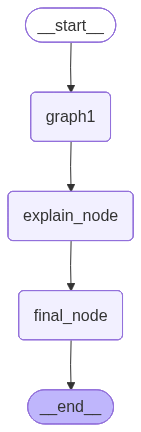

In [10]:
graph2 = StateGraph(State)
graph2.add_node('explain_node', explain_node)
graph2.add_node('graph1', first_graph)
graph2.add_node('final_node', final_node)
graph2.add_edge(START, 'graph1')
graph2.add_edge('graph1', 'explain_node')
graph2.add_edge('explain_node', 'final_node')
graph2.add_edge('final_node', END)
big_graph = graph2.compile()
big_graph